In [1]:
##setup env
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
from matplotlib import cm
import matplotlib.pyplot as plt
from rapidfuzz import process, fuzz
import re

processed_dir = '/Users/audriswong/data-portfolio/projects/seattle-checkouts/data/processed'

#import data
book_checkouts = pd.read_parquet(f'{processed_dir}/book_checkouts.parquet').rename(columns={'title_clean': 'title'}) 
ebook_checkouts = pd.read_parquet(f'{processed_dir}/ebook_checkouts.parquet').rename(columns={'title_clean': 'title'})

#subset physical book and digital ebook checkouts for 2025

book_checkouts_2025 = book_checkouts[book_checkouts['checkoutyear'] == 2025]
ebook_checkouts_2025 = ebook_checkouts[ebook_checkouts['checkoutyear'] == 2025]

# return a sample of the data
print(book_checkouts_2025.head())
print(ebook_checkouts_2025.head())

      usageclass checkouttype materialtype  checkoutyear  checkoutmonth  \
42411   Physical      Horizon         BOOK          2025             10   
42412   Physical      Horizon         BOOK          2025             10   
42413   Physical      Horizon         BOOK          2025             10   
42414   Physical      Horizon         BOOK          2025             10   
42415   Physical      Horizon         BOOK          2025             10   

       checkouts                                          title_raw  \
42411          1                      The ecliptic / Benjamin Wood.   
42412         21  Charlotte's web / E.B. White ; pictures by Gar...   
42413          1                Pilgrim bell : poems / Kaveh Akbar.   
42414          1  Crows : encounters with the wise guys of the a...   
42415          1  A carp for Kimiko / by Virginia Kroll ; illust...   

                                      creator  \
42411                   Wood, Benjamin, 1981-   
42412  White, E. B. (Elw

#### Analysis Question:
##### What is the scope of the dataset?  How many checkouts are there in total?

In [2]:
# Total checkouts and distinct titles per month for physical books
book_monthly = book_checkouts.groupby('month_date').agg(
    total_checkouts=('checkouts', 'sum'),
    distinct_titles=('title', 'nunique'),
    distinct_works=('work_key', 'nunique')
).reset_index()
book_monthly['checkouts'] = pd.to_numeric(book_monthly['total_checkouts'])
book_monthly = book_monthly.sort_values('month_date')

# Total checkouts and distinct titles per month for ebooks
ebook_monthly = ebook_checkouts.groupby('month_date').agg(
    total_checkouts=('checkouts', 'sum'),
    distinct_titles=('title', 'nunique'),
    distinct_works=('work_key', 'nunique')
).reset_index()
ebook_monthly['total_checkouts'] = pd.to_numeric(ebook_monthly['total_checkouts'])
ebook_monthly = ebook_monthly.sort_values('month_date')

# Compute total distinct works across both formats per month
combined_works = (book_monthly[['month_date', 'distinct_works']]
                  .merge(ebook_monthly[['month_date', 'distinct_works']], 
                         on='month_date', suffixes=('_book', '_ebook')))
combined_works['total_works'] = combined_works['distinct_works_book'] + combined_works['distinct_works_ebook']
combined_works['pct_book']    = combined_works['distinct_works_book']  / combined_works['total_works'] * 100
combined_works['pct_ebook']   = combined_works['distinct_works_ebook'] / combined_works['total_works'] * 100

# Compute total checkouts
combined_checkouts = (book_monthly[['month_date', 'total_checkouts']]
                      .merge(ebook_monthly[['month_date', 'total_checkouts']],
                             on='month_date', suffixes=('_book', '_ebook')))
combined_checkouts['total']     = combined_checkouts['total_checkouts_book'] + combined_checkouts['total_checkouts_ebook']
combined_checkouts['pct_book']  = combined_checkouts['total_checkouts_book']  / combined_checkouts['total'] * 100
combined_checkouts['pct_ebook'] = combined_checkouts['total_checkouts_ebook'] / combined_checkouts['total'] * 100


# Calculate average checkouts per title
book_monthly['avg_checkouts_per_title'] = book_monthly['total_checkouts'] / book_monthly['distinct_titles']
ebook_monthly['avg_checkouts_per_title'] = ebook_monthly['total_checkouts'] / ebook_monthly['distinct_titles']
book_monthly['avg_checkouts_per_work'] = book_monthly['total_checkouts'] / book_monthly['distinct_works']
ebook_monthly['avg_checkouts_per_work'] = ebook_monthly['total_checkouts'] / ebook_monthly['distinct_works']

In [3]:
print("Total Book checkouts (digital + physical) across dataset: ", combined_checkouts['total'].sum())

Total Book checkouts (digital + physical) across dataset:  50545037


#### Analysis Question: What is the distribution of total checkouts across digital and physical formats?  How has this evolved over time?

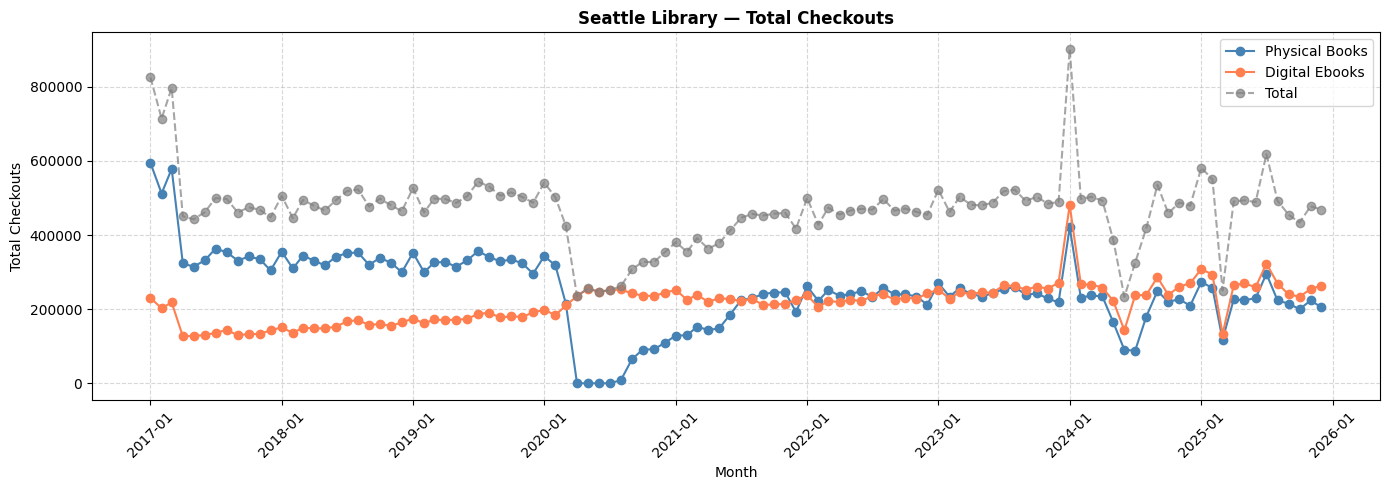

✅ Total Checkouts saved


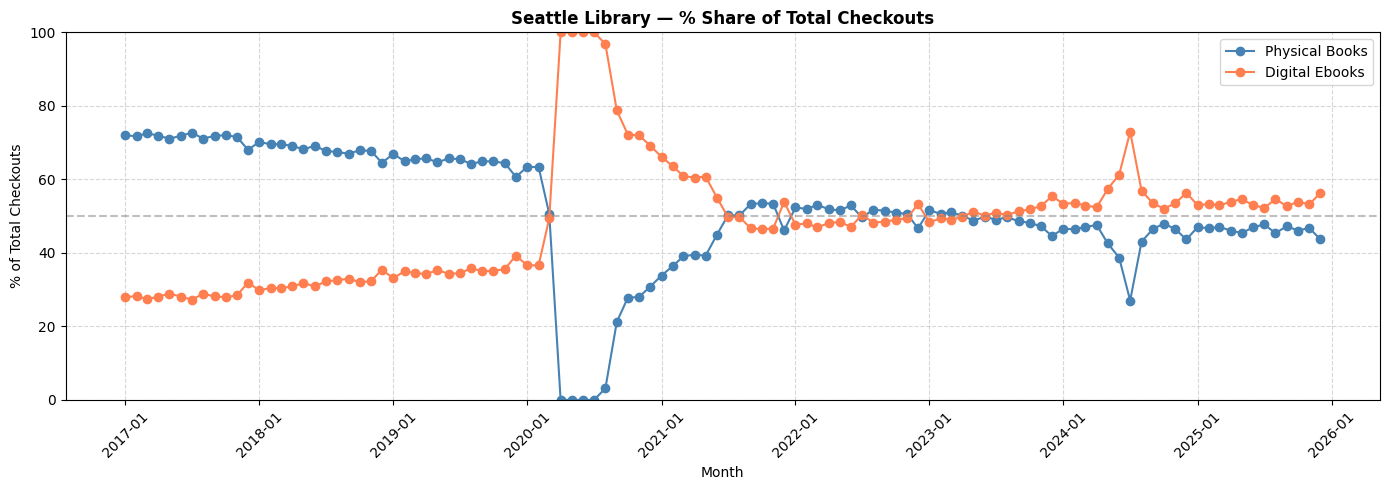

✅ % Share of Total Checkouts saved


In [21]:
#Plot digital + physical book checkout trends over time since 2017
# Plot Total Checkouts
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(book_monthly['month_date'], book_monthly['total_checkouts'],
        marker='o', label='Physical Books', color='steelblue')
ax.plot(ebook_monthly['month_date'], ebook_monthly['total_checkouts'],
        marker='o', label='Digital Ebooks', color='coral')
# Combined total line
ax.plot(combined_checkouts['month_date'], combined_checkouts['total'],
        marker='o', label='Total', color='grey', linestyle='--', alpha=0.7)
ax.set_title('Seattle Library — Total Checkouts', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Checkouts')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('/Users/audriswong/data-portfolio/projects/seattle-checkouts/outputs/figures/total_checkouts.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Total Checkouts saved")

# Plot % Share of Total Checkouts
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(combined_checkouts['month_date'], combined_checkouts['pct_book'],
        marker='o', label='Physical Books', color='steelblue')
ax.plot(combined_checkouts['month_date'], combined_checkouts['pct_ebook'],
        marker='o', label='Digital Ebooks', color='coral')
ax.axhline(50, color='grey', linestyle='--', alpha=0.5)
ax.set_title('Seattle Library — % Share of Total Checkouts', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('% of Total Checkouts')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('/Users/audriswong/data-portfolio/projects/seattle-checkouts/outputs/figures/pct_share_total_checkouts.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ % Share of Total Checkouts saved")

#### Learnings:
##### Total monthly checkouts declined during COVID-19 library branch closures (March–August 2020) and physical checkouts reaching near zero.  Digital checkout volume partially offset the loss but did not fully recover total checkout volume. 
##### Post-reopening recovery was gradual, with total combined checkout volume returning to pre-COVID levels by mid-2021. 
##### By 2023, total volume had stabilized and digital checkouts consistently exceed physical checkouts.
##### Physical books made up ~72% of total checkouts in 2017, declining slowly to ~64% by early 2020. COVID branch closures moved virtually all checkouts online to digital. After branches reopened in August 2020, physical checkouts recovered steadily, catching up with with digital by July 2021. Both formats remained roughly equal until September 2023, after which digital consistently exceeds physical checkouts. As of 2025, the split is approximately 46% physical / 54% digital.

#### Analysis Question: 
##### How consistent is the annual checkout mix shift from physical to digital from November to December?  Is the reversal of the trend from digital back to physical from December to January similarly consistent?

In [5]:
combined_checkouts = (book_monthly[['month_date', 'total_checkouts']]
                      .merge(ebook_monthly[['month_date', 'total_checkouts']],
                             on='month_date', suffixes=('_book', '_ebook')))
combined_checkouts['total']     = combined_checkouts['total_checkouts_book'] + combined_checkouts['total_checkouts_ebook']
combined_checkouts['pct_ebook'] = combined_checkouts['total_checkouts_ebook'] / combined_checkouts['total'] * 100
combined_checkouts['pct_book'] = 100 - (combined_checkouts['total_checkouts_ebook'] / combined_checkouts['total'] * 100)

combined_checkouts['year']      = combined_checkouts['month_date'].dt.year
combined_checkouts['month']     = combined_checkouts['month_date'].dt.month
combined_checkouts              = combined_checkouts.sort_values('month_date')
combined_checkouts['pct_ebook_mom_delta'] = combined_checkouts['pct_ebook'].diff()

# Nov -> Dec: both in same year
nov_dec = (combined_checkouts[combined_checkouts['month'] == 12]
           [['year', 'pct_ebook_mom_delta']]
           .rename(columns={'pct_ebook_mom_delta': 'Nov → Dec (pp)'}))

# Dec -> Jan: Jan year - 1 to align with prior year's Nov/Dec
dec_jan = (combined_checkouts[combined_checkouts['month'] == 1]
           [['year', 'pct_ebook_mom_delta']]
           .assign(year=lambda x: x['year'] - 1)
           .rename(columns={'pct_ebook_mom_delta': 'Dec → Jan (pp)'}))

summary = (nov_dec.merge(dec_jan, on='year', how='outer')
           .rename(columns={'year': 'Year'})
           .sort_values('Year')
           .round(2))

print(f"== MoM Delta in Ebook Share of Total Checkouts ==\n")
print(summary[summary['Year'] >= 2017].to_string(index=False))

== MoM Delta in Ebook Share of Total Checkouts ==

 Year  Nov → Dec (pp)  Dec → Jan (pp)
 2017            3.51           -2.14
 2018            3.23           -2.36
 2019            3.71           -2.68
 2020           -2.78           -3.03
 2021            7.27           -6.25
 2022            3.90           -4.95
 2023            2.68           -2.07
 2024            2.83           -3.38
 2025            3.06             NaN


#### Learnings:
##### In every year except 2020, ebook checkout share rises in December relative to November, then reverses in January. Excluding 2020, when physical checkout volume is still recovering after COVID branch closures, the median November -> December increase is +3.4 pp, followed by a median reversal of -2.9 pp in January. This shift and recovery consistently holds across 8 years of data and has direct implications for ebook license capacity planning in Q4.

#### Analysis Question:
##### What seasonal trends are there in checkout volume, turnover, and range in titles checked out?

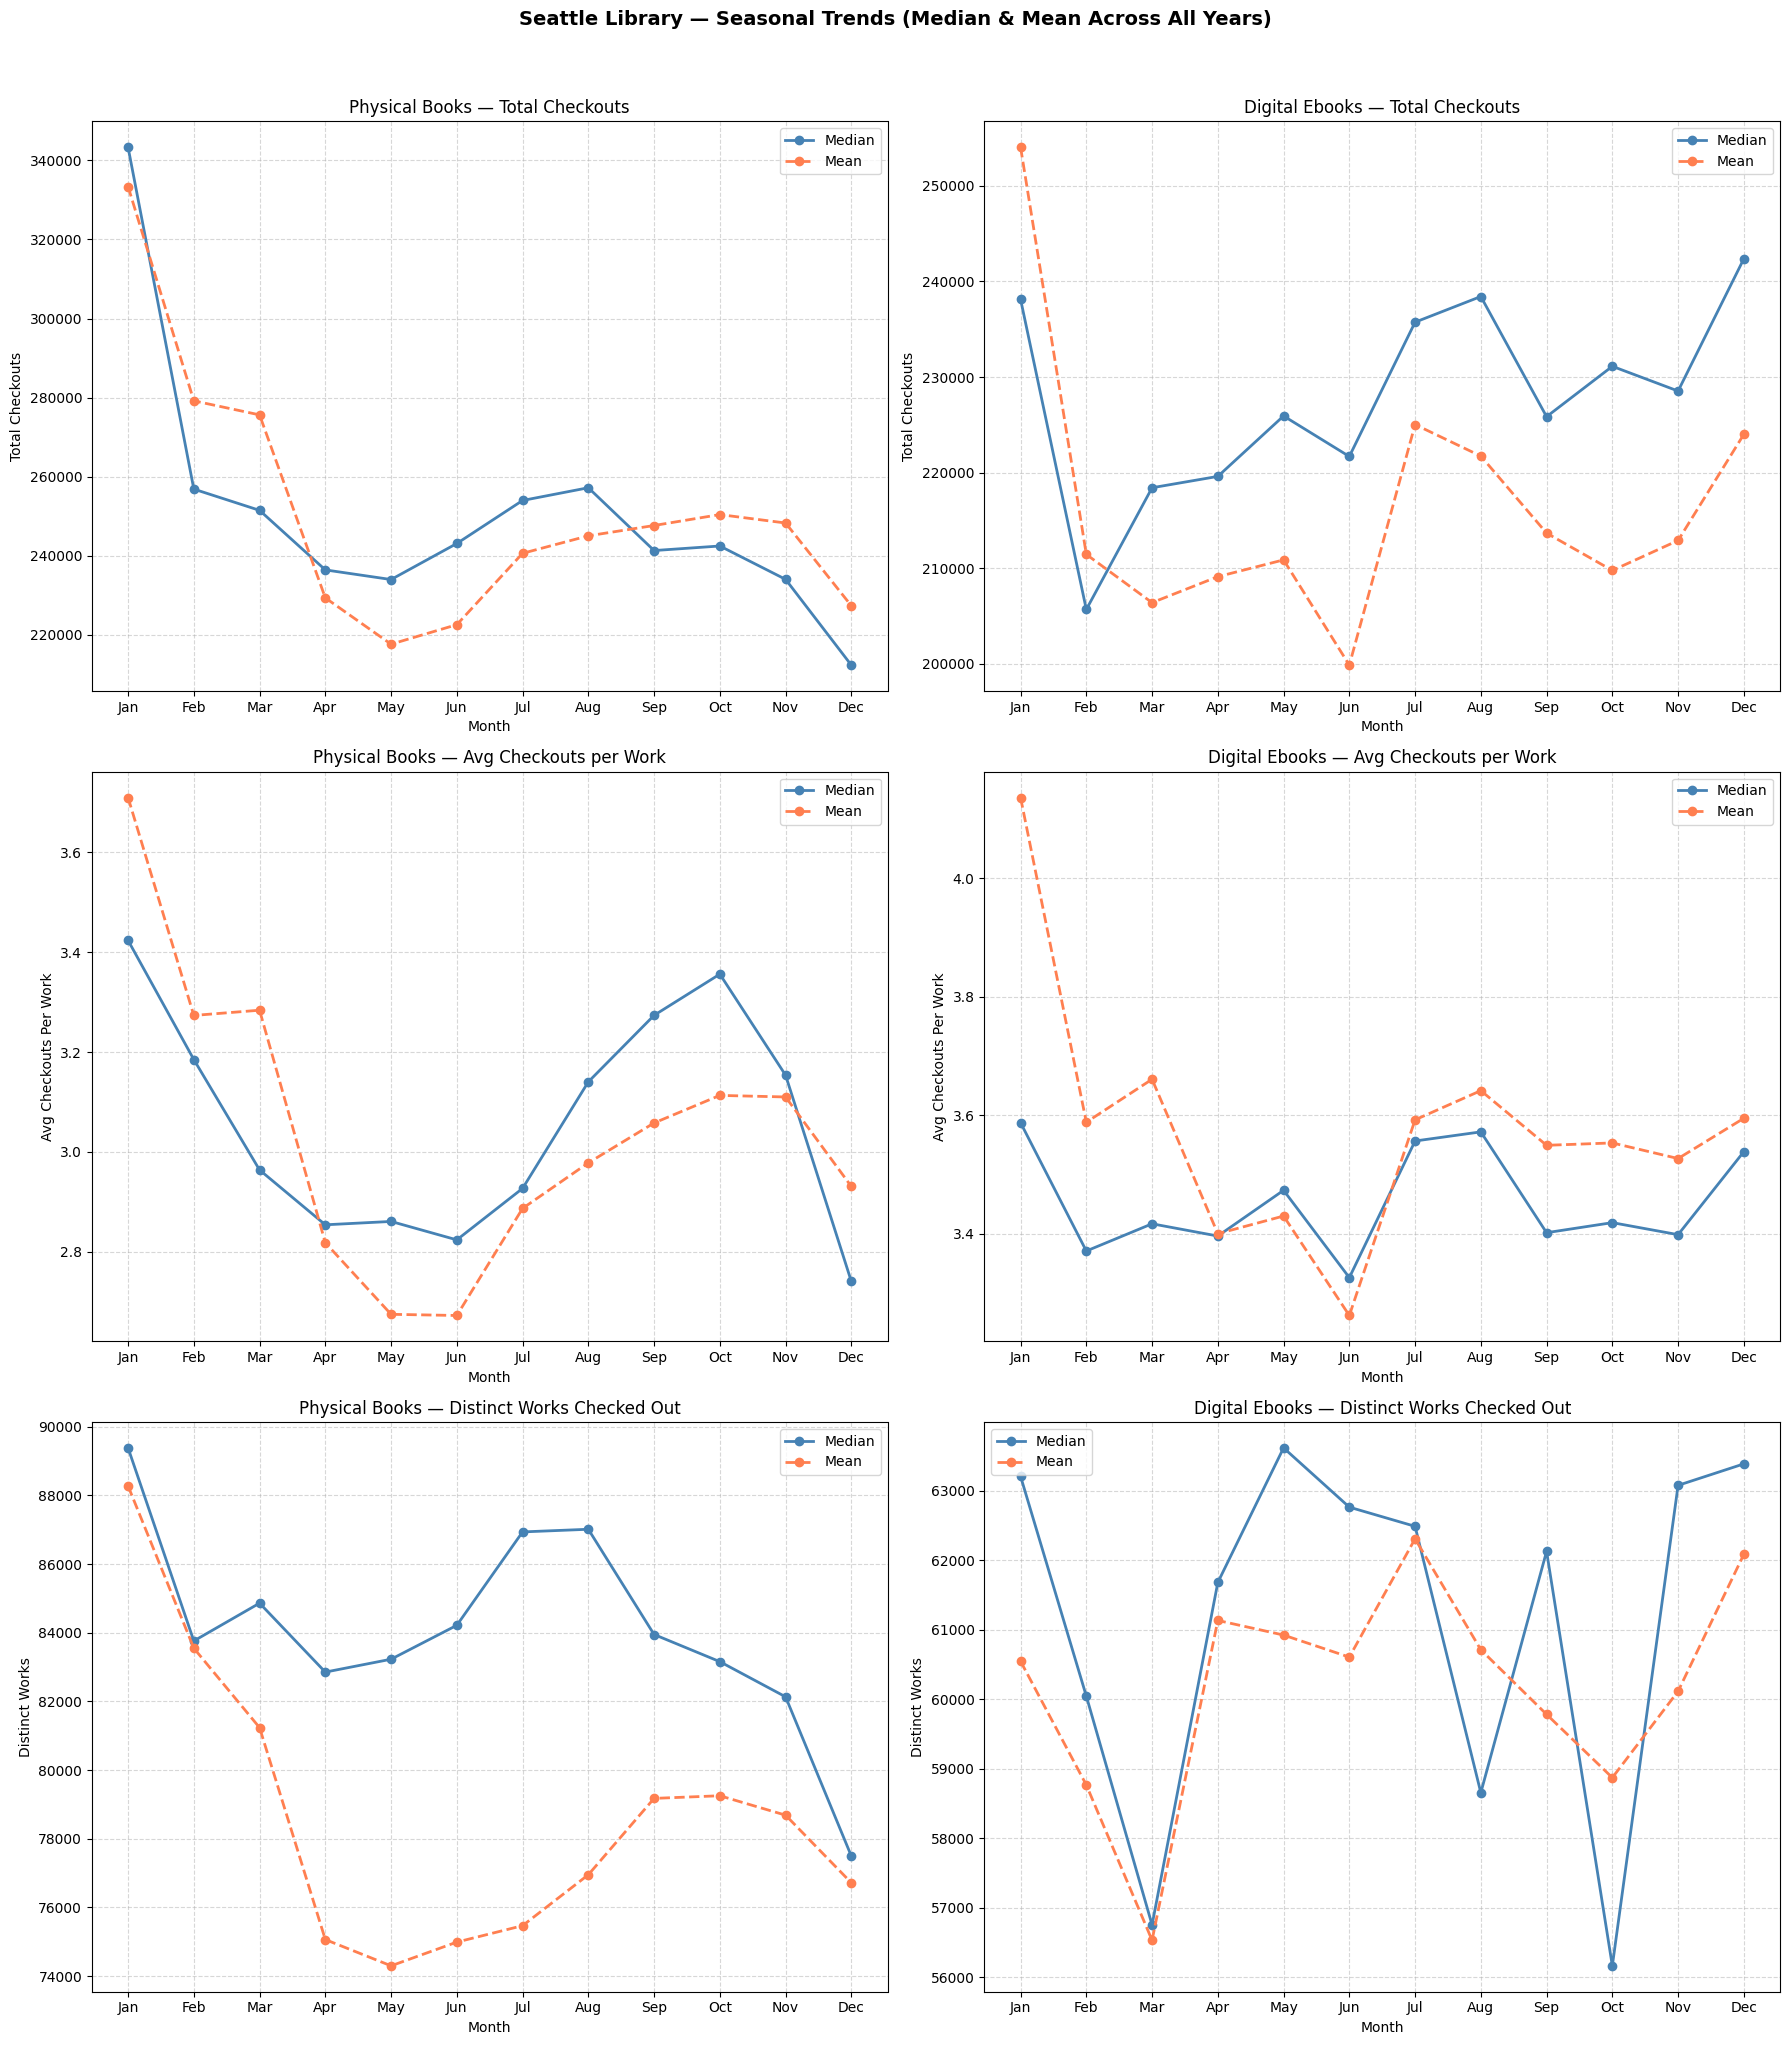

✅ Chart saved to outputs/figures/


In [6]:
# Plot total checkouts, average checkouts, and distinct works checked out 
# by month aggregated over every year to identify seasonal trends  
book_monthly['year'] = book_monthly['month_date'].dt.year
book_monthly['month'] = book_monthly['month_date'].dt.month
ebook_monthly['year'] = ebook_monthly['month_date'].dt.year
ebook_monthly['month'] = ebook_monthly['month_date'].dt.month

fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle('Seattle Library — Seasonal Trends (Median & Mean Across All Years)',
             fontsize=14, fontweight='bold', y=1.02)

charts = [
    (axes[0, 0], book_monthly,  'total_checkouts',        'Physical Books — Total Checkouts'),
    (axes[0, 1], ebook_monthly, 'total_checkouts',        'Digital Ebooks — Total Checkouts'),
    (axes[1, 0], book_monthly,  'avg_checkouts_per_work', 'Physical Books — Avg Checkouts per Work'),
    (axes[1, 1], ebook_monthly, 'avg_checkouts_per_work', 'Digital Ebooks — Avg Checkouts per Work'),
    (axes[2, 0], book_monthly,  'distinct_works',         'Physical Books — Distinct Works Checked Out'),
    (axes[2, 1], ebook_monthly, 'distinct_works',         'Digital Ebooks — Distinct Works Checked Out'),
]

for ax, data, metric, title in charts:
    monthly_stats = data.groupby('month')[metric].agg(['median', 'mean']).reset_index()
    
    ax.plot(monthly_stats['month'], monthly_stats['median'],
            marker='o', linewidth=2, label='Median', color='steelblue')
    ax.plot(monthly_stats['month'], monthly_stats['mean'],
            marker='o', linewidth=2, label='Mean', color='coral', linestyle='--')
    
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/Users/audriswong/data-portfolio/projects/seattle-checkouts/outputs/figures/yoy_seasonal_trends_agg.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to outputs/figures/")

#### Learnings:
##### Total checkouts are elevated in July/ August (school summer holidays) for both digital and physical formats.  physical summer growth is driven by a wider range of titles being borrowed (higher distinct titles checked out), while digital summer growth is caused by the same number of titles circulating faster (higher turnover from higher average checkouts per work).
##### In March (National Reading Month), we observe an increase in range of physical titles checked out, suggesting that patrons are receptive to exploring new titles within the library's collection.
##### January is the peak in circulation as measured by total checkouts and circulation speed (turnover from average checkouts per work).

#### Analysis Question:
##### How have different physical book genres changed in popularity over time?

In [7]:
# define function to extract genre from keywords and test performance
# See a sample of raw subjects values
print("Sample subjects values:")
book_checkouts['subjects'].dropna().sample(20).tolist()

# Check null rate
null_rate = book_checkouts['subjects'].isna().mean() * 100
print(f"Null subjects: {null_rate:.1f}%")

# See most common subject strings
print("\nMost common subjects:")
book_checkouts['subjects'].value_counts().head(20)

# keyword -> genre mapping
genre_keywords = {
    'Mystery/Thriller': ['mystery', 'detective', 'crime', 'thriller', 'suspense'],
    'Science Fiction':  ['science fiction', 'sci-fi'],
    'Fantasy':          ['fantasy'],
    'Romance':          ['romance', 'love stories'],
    'Horror':           ['horror'],
    'Historical':       ['historical fiction', 'history'],
    'Biography/Memoir': ['biography', 'memoir', 'autobiography'],
    'Self-Help':        ['self-help', 'personal development', 'motivation', 'success'],
    'Cooking':          ['cooking', 'cookbooks', 'baking', 'vegan cooking', 'food'],
    'Poetry':           ['poetry'],
    'Graphic Novel':    ['graphic novels', 'comics', 'manga'],
    'Juvenile':         ['juvenile', 'childrens', "children's", 'picture book', 'young adult'],
    'Crafts':           ['knitting', 'quilting', 'sewing', 'crafts'],
    'Health/Wellness':  ['health', 'wellness', 'fitness', 'diet', 'medicine'],
    'Business':         ['business', 'economics', 'finance', 'management'],
    'Science/Nature':   ['science', 'nature', 'animals', 'dinosaurs'],
    'Religion':         ['religion', 'spiritual', 'christian', 'bible'],
    'Travel':           ['travel', 'geography'],
    'Art/Design':       ['art', 'interior decoration', 'design', 'photography'],
    'Humor':            ['humor'],
    'Nonfiction':       ['nonfiction'],
    'Fiction':          ['fiction', 'novel', 'short stories', 'literature'],
}

def extract_genre(subjects):
    if pd.isna(subjects):
        return 'Unknown'
    subjects_lower = str(subjects).lower()
    for genre, keywords in genre_keywords.items():
        if any(kw in subjects_lower for kw in keywords):
            return genre
    return 'Other'

# Extract physical and digital book genres from keywords
book_checkouts['genre'] = book_checkouts['subjects'].apply(extract_genre)
ebook_checkouts['genre'] = ebook_checkouts['subjects'].apply(extract_genre)

# Check extraction coverage
print("Physical Books - Genre distribution:")
print(book_checkouts['genre'].value_counts())

print(f"\nUnclassified (Other/Unknown): {(book_checkouts['genre'].isin(['Other','Unknown'])).mean()*100:.1f}%")

# Spot check 'Other' genre to see what's being missed
print("\nPhysical Books - Sample unclassified subjects:")
book_checkouts[book_checkouts['genre'] == 'Other']['subjects'].value_counts().head(20)

print("Digital EBooks - Genre distribution:")
print(ebook_checkouts['genre'].value_counts())

print(f"\nUnclassified (Other/Unknown): {(ebook_checkouts['genre'].isin(['Other','Unknown'])).mean()*100:.1f}%")

# Spot check 'Other' to see what's being missed
print("\nDigital EBooks - Sample unclassified subjects:")
ebook_checkouts[ebook_checkouts['genre'] == 'Other']['subjects'].value_counts().head(20)

Sample subjects values:
Null subjects: 1.5%

Most common subjects:
Physical Books - Genre distribution:
genre
Juvenile            2561198
Other               1379402
Mystery/Thriller     834843
Historical           802059
Fiction              459614
Biography/Memoir     459455
Fantasy              386871
Cooking              384427
Graphic Novel        380479
Science Fiction      273977
Art/Design           236081
Romance              215858
Unknown              138366
Poetry               110773
Business             110342
Travel               103777
Health/Wellness       94219
Religion              86051
Science/Nature        80169
Horror                63110
Humor                 57999
Crafts                56152
Self-Help             52039
Nonfiction             1970
Name: count, dtype: int64

Unclassified (Other/Unknown): 16.3%

Physical Books - Sample unclassified subjects:
Digital EBooks - Genre distribution:
genre
Mystery/Thriller    1489932
Juvenile             912543
Romance 

subjects
Beginning Reader                   489
Comic and Graphic Books            166
Essays                              21
Mathematics                         10
Family & Relationships               8
Children                             7
NA                                   2
Self-Improvement                     2
Military                             2
New Age                              1
Sociology, Sports & Recreations      1
Biology                              1
Name: count, dtype: int64

In [8]:
#define genre mapping function for top 10% of works by monthly popularity
def top200_genre_breakdown(df, year_col='checkoutyear', month_col='checkoutmonth'):
    results = []
    
    for (year, month), group in df.groupby([year_col, month_col]):
        # Get top 200 works by checkout volume
        top200 = (group.groupby('work_key')
                  .agg(total_checkouts=('checkouts', 'sum'),
                       genre=('genre', 'first'))
                  .reset_index()
                  .sort_values('total_checkouts', ascending=False)
                  .head(200))
        
        # Genre breakdown of those top 200
        genre_breakdown = (top200.groupby('genre')
                           .agg(num_works=('work_key', 'count'),
                                total_checkouts=('total_checkouts', 'sum'))
                           .reset_index())
        genre_breakdown['pct_of_top200_works']     = (genre_breakdown['num_works'] / 200 * 100).round(1)
        genre_breakdown['pct_of_top200_checkouts'] = (genre_breakdown['total_checkouts'] / genre_breakdown['total_checkouts'].sum() * 100).round(1)
        genre_breakdown['checkoutyear']  = year
        genre_breakdown['checkoutmonth'] = month
        
        results.append(genre_breakdown)
    
    return pd.concat(results, ignore_index=True).sort_values(['checkoutyear', 'checkoutmonth', 'pct_of_top200_checkouts'], ascending=[True, True, False])

# extract genres from top 200 monthly books, ebooks
book_top200_genre  = top200_genre_breakdown(book_checkouts)
ebook_top200_genre = top200_genre_breakdown(ebook_checkouts)

# Count distinct genres represented per month for each format
book_genres_per_month  = book_top200_genre.groupby('checkoutmonth')['genre'].nunique()
ebook_genres_per_month = ebook_top200_genre.groupby('checkoutmonth')['genre'].nunique()

# Print performance statistics (# median, mean number of genres represented in top 10% of monthly checkouts)
print("📚 Physical Books — Genres in Top 10% per Month")
print(f"  Median: {book_genres_per_month.median():.1f}")
print(f"  Mean:   {book_genres_per_month.mean():.1f}")

print("\n📱 Digital Ebooks — Genres in Top 10% per Month")
print(f"  Median: {ebook_genres_per_month.median():.1f}")
print(f"  Mean:   {ebook_genres_per_month.mean():.1f}")

📚 Physical Books — Genres in Top 10% per Month
  Median: 23.0
  Mean:   23.0

📱 Digital Ebooks — Genres in Top 10% per Month
  Median: 17.0
  Mean:   17.1


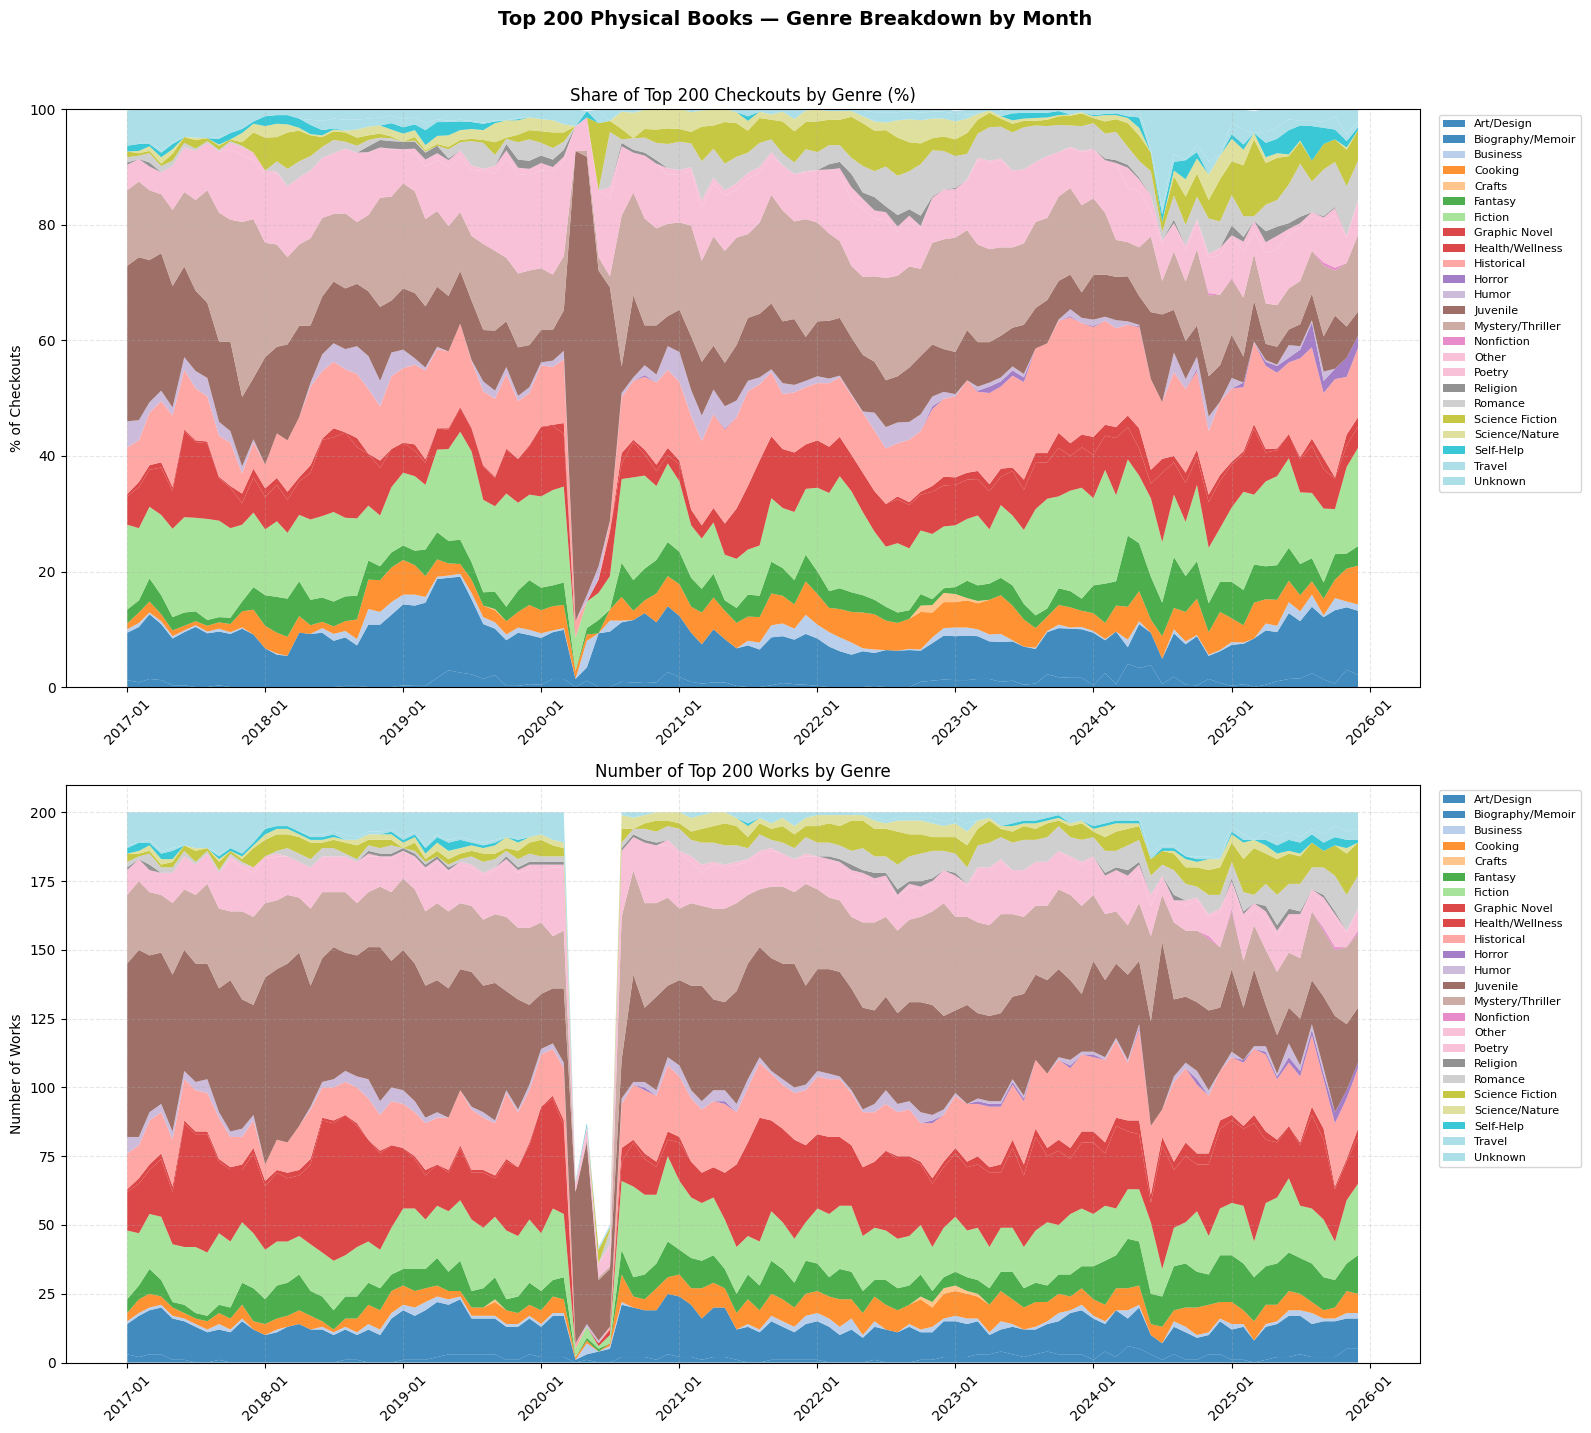

✅ Chart saved to outputs/figures/


In [9]:
#shared color map for plotting
all_genres = sorted(set(book_top200_genre['genre'].unique()) | set(ebook_top200_genre['genre'].unique()))
genre_colors = dict(zip(all_genres, cm.tab20(np.linspace(0, 1, len(all_genres)))))

# plot physical books
# Create month_date for plotting
book_top200_genre['month_date'] = pd.to_datetime(
    book_top200_genre['checkoutyear'].astype(str) + '-' +
    book_top200_genre['checkoutmonth'].astype(str).str.zfill(2) + '-01'
)

# Pivot for stacked area chart — % of top 200 checkouts by genre per month
book_genre_pivot = book_top200_genre.pivot_table(
    index='month_date',
    columns='genre',
    values='pct_of_top200_checkouts',
    aggfunc='sum'
).fillna(0).sort_index()

# Pull in genre + colors from preset color map
genres = book_genre_pivot.columns.tolist()
colors = [genre_colors[g] for g in genres]


# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
fig.suptitle('Top 200 Physical Books — Genre Breakdown by Month',
             fontsize=14, fontweight='bold', y=1.02)

# Stacked area chart — % of checkouts
axes[0].stackplot(book_genre_pivot.index,
                  [book_genre_pivot[g] for g in genres],
                  labels=genres,
                  colors=colors,
                  alpha=0.85)
axes[0].set_title('Share of Top 200 Checkouts by Genre (%)')
axes[0].set_ylabel('% of Checkouts')
axes[0].set_ylim(0, 100)
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Stacked area chart — number of works
book_genre_pivot_works = book_top200_genre.pivot_table(
    index='month_date',
    columns='genre',
    values='num_works',
    aggfunc='sum'
).fillna(0).sort_index()

axes[1].stackplot(book_genre_pivot_works.index,
                  [book_genre_pivot_works[g] for g in genres],
                  labels=genres,
                  colors=colors,
                  alpha=0.85)
axes[1].set_title('Number of Top 200 Works by Genre')
axes[1].set_ylabel('Number of Works')
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/audriswong/data-portfolio/projects/seattle-checkouts/outputs/figures/top200_book_genre_breakdown.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to outputs/figures/")

#### Learnings
##### Since the post-COVID reopening (June 2020), Fiction, Historical, and Biography/Memoir have dominated the top 3 in popularity. 
##### All genres collapsed during COVID closures except Juvenile, confirming that libraries remained a critical reading resource for children.

#### Analysis Question:
##### 

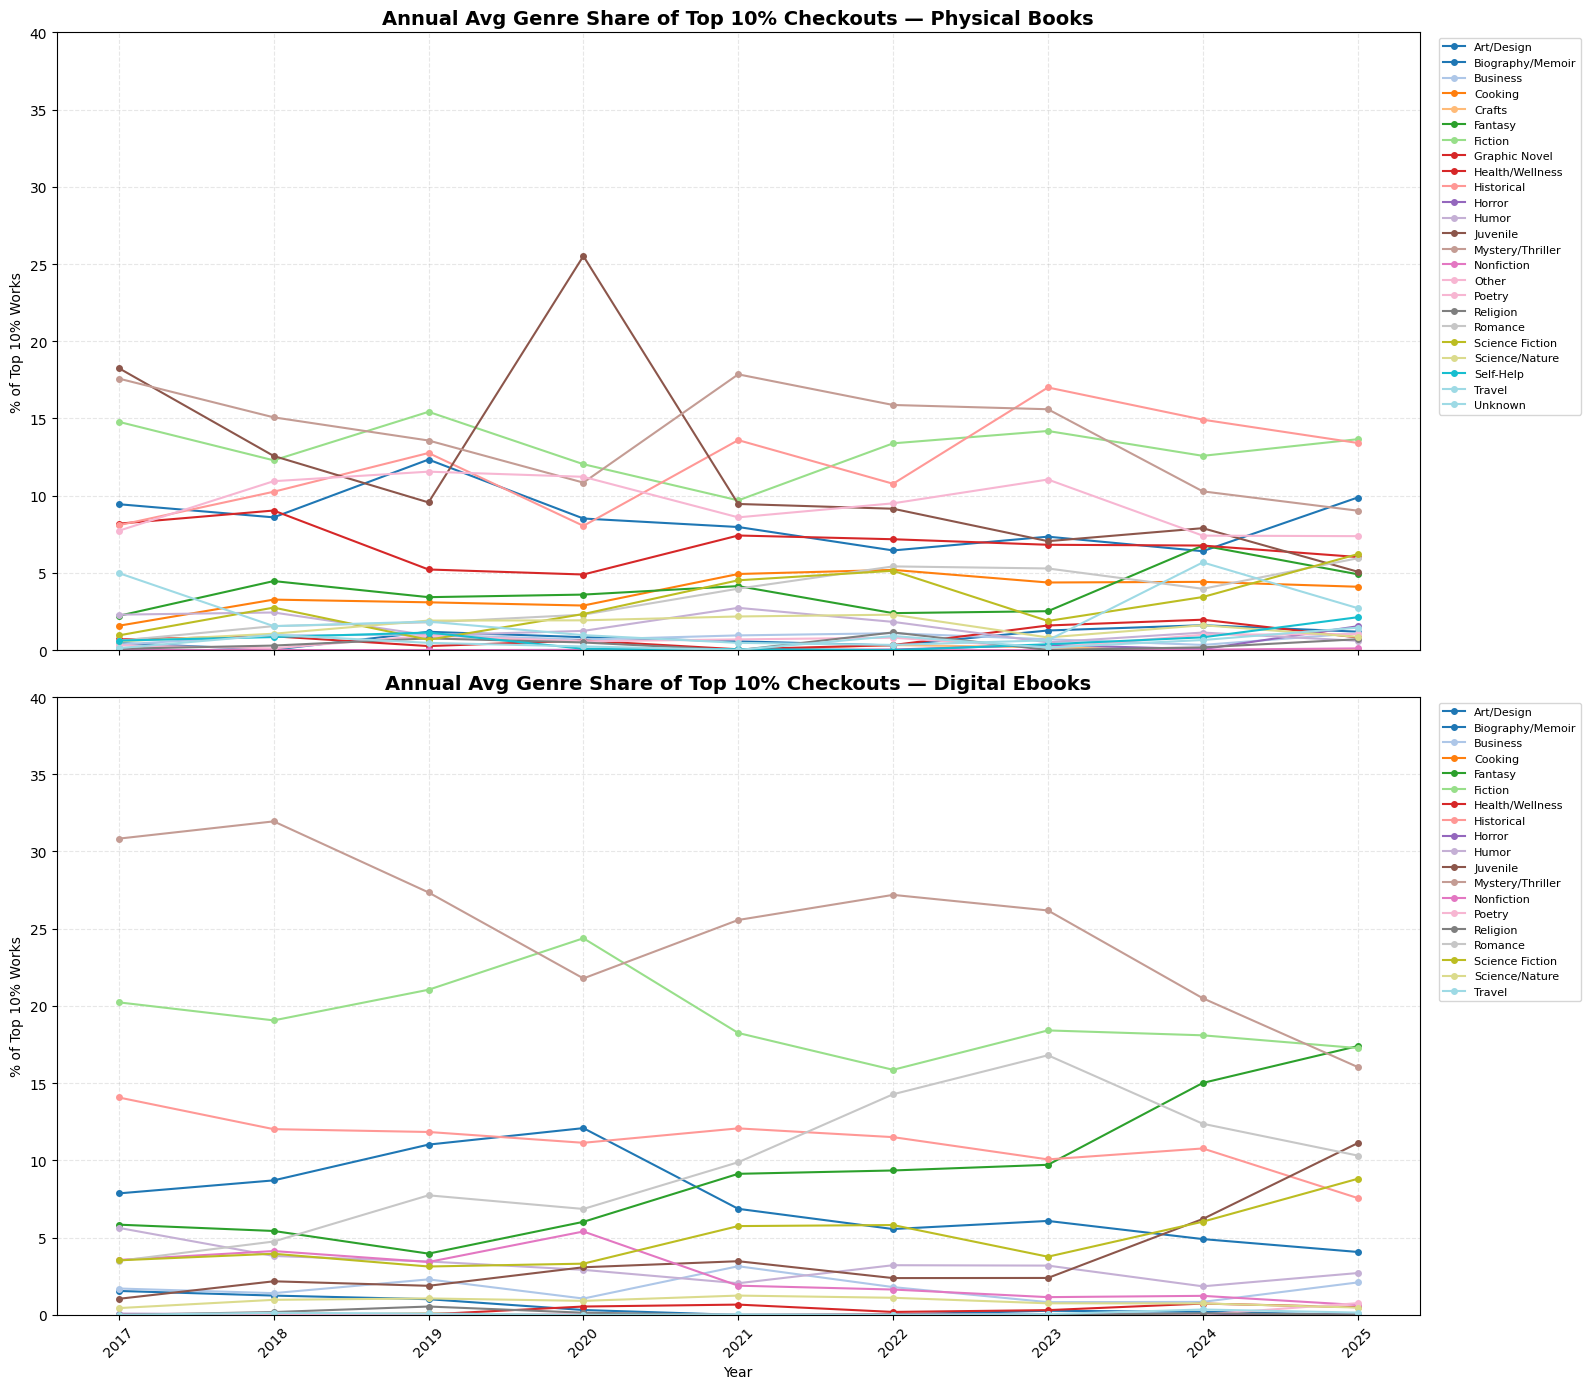

✅ Chart saved to outputs/figures/


In [10]:
#pivot top 200 monthly ebook by genre data to calculate share
# Create month_date for plotting
ebook_top200_genre['month_date'] = pd.to_datetime(
    ebook_top200_genre['checkoutyear'].astype(str) + '-' +
    ebook_top200_genre['checkoutmonth'].astype(str).str.zfill(2) + '-01'
)

ebook_genre_pivot = ebook_top200_genre.pivot_table(
    index='month_date',
    columns='genre',
    values='pct_of_top200_checkouts',
    aggfunc='sum'
).fillna(0).sort_index()


# plot genre share of yearly checkouts 
book_genre_annual = book_genre_pivot.copy()
book_genre_annual.index = book_genre_annual.index.year
book_genre_annual = book_genre_annual.groupby(book_genre_annual.index).mean()

ebook_genre_annual = ebook_genre_pivot.copy()
ebook_genre_annual.index = ebook_genre_annual.index.year
ebook_genre_annual = ebook_genre_annual.groupby(ebook_genre_annual.index).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14), sharex=True)

# Physical Books
ax1.set_title('Annual Avg Genre Share of Top 10% Checkouts — Physical Books',
              fontsize=14, fontweight='bold')
for genre in book_genre_annual.columns:
    ax1.plot(book_genre_annual.index, book_genre_annual[genre],
             label=genre, color=genre_colors[genre], linewidth=1.5, marker='o', markersize=4)
ax1.set_ylabel('% of Top 10% Works')
ax1.set_ylim(0, 40)
ax1.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.3)

# Ebooks
ax2.set_title('Annual Avg Genre Share of Top 10% Checkouts — Digital Ebooks',
              fontsize=14, fontweight='bold')
for genre in ebook_genre_annual.columns:
    ax2.plot(ebook_genre_annual.index, ebook_genre_annual[genre],
             label=genre, color=genre_colors[genre], linewidth=1.5, marker='o', markersize=4)
ax2.set_ylabel('% of Top 10% Works')
ax2.set_xlabel('Year')
ax2.set_ylim(0, 40)
ax2.set_xticks(ebook_genre_annual.index)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/audriswong/data-portfolio/projects/seattle-checkouts/outputs/figures/genre_share_annual_combined.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to outputs/figures/")

#### Learnings:
##### The top 10% most popular physical books spans 23 genres while popular ebooks spans 17, confirming that physical collections serve a broader range of reader interests. 
##### Ebook genres have shifted within the top 10 in terms of popularity, reflecting changing reader tastes. Romance grew from 10% -> 24% in July 2023, Fantasy grew from ~7% to a peak of 22% in March 2025, and Juvenile has grown to ~14% as of early 2025. 
##### These emerging genres displaced Nonfiction (19% in 2020, now <2%) and Biography/Memoir (15% in 2020, now ~5%), both of which were genre leaders during COVID in 2020. By comparison, popular physical book genre share is more stable across the same period.
##### The limited overlap in physical and digital top 3 genres suggests that each format serves readers with different genre interests, and that the two collections should be treated as complements rather than substitutes.

#### Analysis Question:
##### What genre-specific seasonal trends are there that could shape patron engagement strategy?

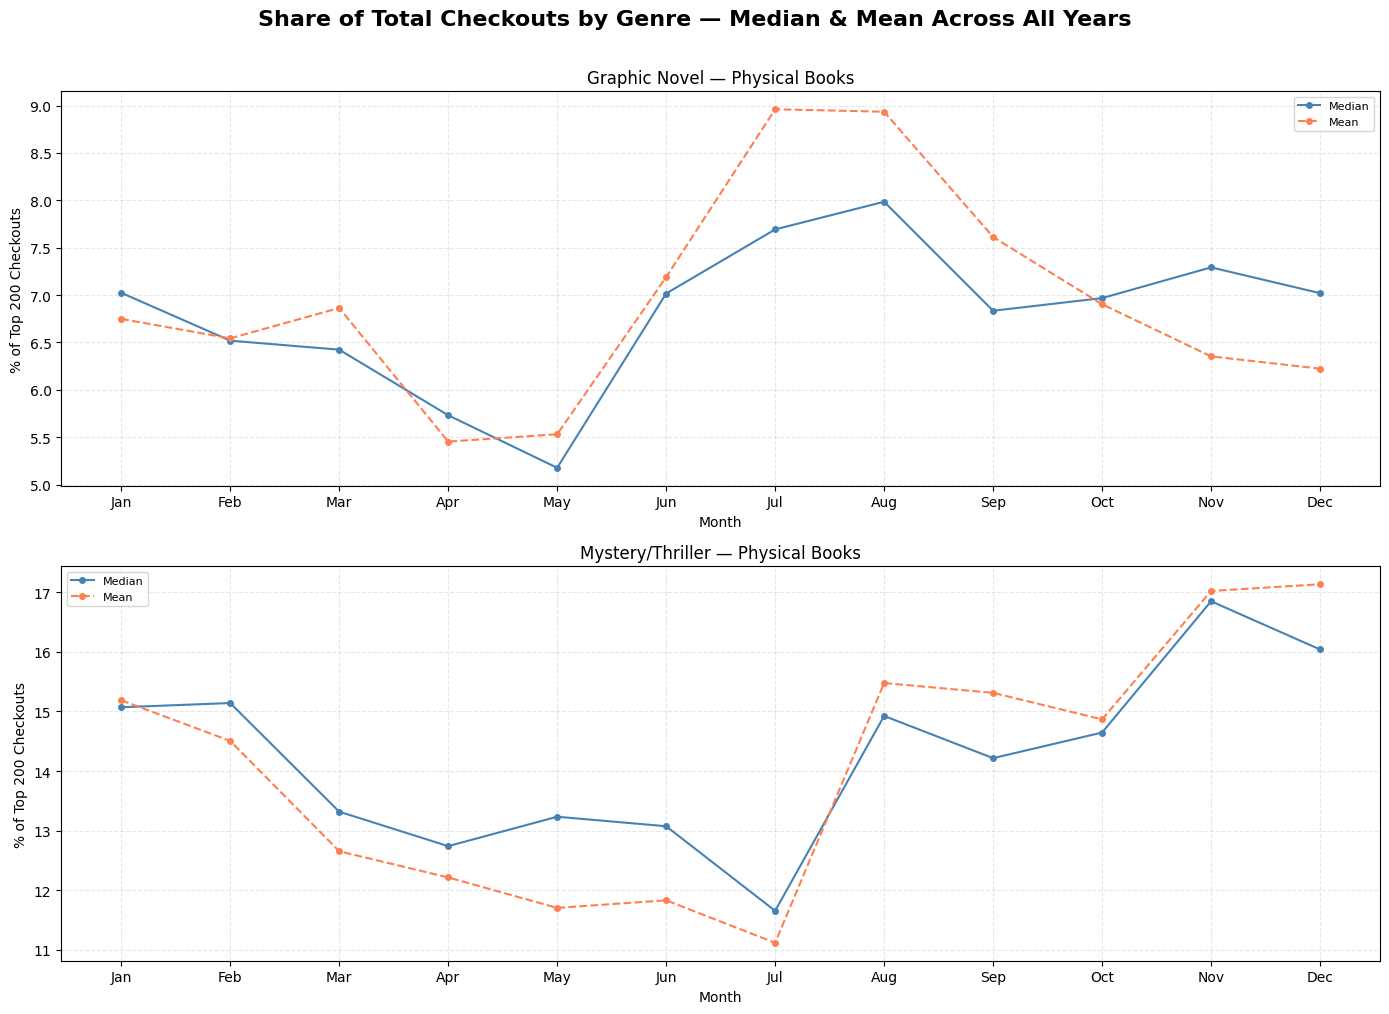

✅ All genres saved to one image


In [11]:
# share of total checkouts per genre per month for books and ebooks 
# subset to interesting genres only: Mystery/Thriller and Graphic Novel
def add_checkout_share(df):
    monthly_total = df.groupby(['checkoutyear', 'checkoutmonth'])['total_checkouts'].transform('sum')
    df = df.copy()
    df['checkout_share'] = df['total_checkouts'] / monthly_total * 100
    return df

book_share  = add_checkout_share(book_top200_genre)

subset_genres = ['Graphic Novel', 'Mystery/Thriller']
n_genres   = len(subset_genres)

fig, axes = plt.subplots(n_genres, 1, figsize=(14, 5 * n_genres))
fig.suptitle('Share of Total Checkouts by Genre — Median & Mean Across All Years',
             fontsize=16, fontweight='bold', y=1.01)

for row, genre in enumerate(subset_genres):
    book_genre   = book_share[book_share['genre'] == genre]
    monthly_stats = book_genre.groupby('checkoutmonth')['checkout_share'].agg(['median', 'mean']).reset_index()
    
    axes[row].plot(monthly_stats['checkoutmonth'], monthly_stats['median'],
                   marker='o', markersize=4, linewidth=1.5,
                   label='Median', color='steelblue')
    axes[row].plot(monthly_stats['checkoutmonth'], monthly_stats['mean'],
                   marker='o', markersize=4, linewidth=1.5,
                   label='Mean', color='coral', linestyle='--')
    axes[row].set_title(f'{genre} — Physical Books')
    axes[row].set_xlabel('Month')
    axes[row].set_ylabel('% of Top 200 Checkouts')
    axes[row].set_xticks(range(1, 13))
    axes[row].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                               'Jul','Aug','Sep','Oct','Nov','Dec'])
    axes[row].legend(fontsize=8)
    axes[row].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/audriswong/data-portfolio/projects/seattle-checkouts/outputs/figures/checkout_share_by_genre_agg.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ All genres saved to one image")

#### Learnings:
##### Checkouts of physical Graphic Novels spike in June/July, consistent with increased children's readership during school summer holidays. 
##### Checkouts of physical Mystery/Thriller works spike in November across both physical and digital formats
##### These consistent, annual trends can inform seasonal reader's advisory programming and curated displays.

#### Analysis Questions:
##### How long do popular books stay popular?  For example, do the top 10 most popular works stay in the top 10 in the second, third, etc. month?

In [12]:
# add ranking (based on volume of monthly checkouts) per work 

def works_with_monthly_rank(df, year_col='checkoutyear', month_col='checkoutmonth'):
    results = []
    for (year, month), group in df.groupby([year_col, month_col]):
        ranked = (group.groupby('work_key')
                .agg(total_checkouts=('checkouts', 'sum'),
                     genre=('genre', 'first'),
                     title=('title', 'first'),
                     creator=('creator_clean', 'first'),
                     month_date = ('month_date', 'first'))
                .reset_index()
                .sort_values('total_checkouts', ascending=False))
        ranked['month_checkout_rank'] = range(1, len(ranked) + 1)
        ranked['checkoutyear']  = year
        ranked['checkoutmonth'] = month
        results.append(ranked)
    return pd.concat(results, ignore_index=True)

book_ranked  = works_with_monthly_rank(book_checkouts)
ebook_ranked = works_with_monthly_rank(ebook_checkouts)

In [13]:
# define popularity tenure function, defined as number of consecutive months
# a work stays in the top 10 list
def max_consecutive_months(dates):
    """Given a series of month_dates, return the longest consecutive run in months"""
    if len(dates) == 0:
        return 0
    dates_sorted = sorted(pd.to_datetime(dates))
    max_run = 1
    current_run = 1
    for i in range(1, len(dates_sorted)):
        diff = (dates_sorted[i].year - dates_sorted[i-1].year) * 12 + \
               (dates_sorted[i].month - dates_sorted[i-1].month)
        if diff == 1:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 1
    return max_run

# Compute consecutive months in top 10 per physical book
book_consecutive = (book_ranked[book_ranked['month_checkout_rank'] <= 10]
                    .sort_values('month_date')
                    .groupby('work_key')
                    .agg(
                        max_consecutive=('month_date', max_consecutive_months),
                        genre=('genre', 'first'),
                        title=('title', 'first'),
                        entry_month=('checkoutmonth', 'first'),  # month book first entered top 10
                        entry_year=('checkoutyear', 'first')
                    )
                    .reset_index())

# Sort genres by median consecutive months descending
book_genre_order = (book_consecutive.groupby('genre')['max_consecutive']
               .median()
               .sort_values(ascending=False)
               .index.tolist())

# Compute consecutive months in top 10 per ebook
ebook_consecutive = (ebook_ranked[ebook_ranked['month_checkout_rank'] <= 10]
                    .sort_values('month_date')
                    .groupby('work_key')
                    .agg(
                        max_consecutive=('month_date', max_consecutive_months),
                        genre=('genre', 'first'),
                        title=('title', 'first'),
                        entry_month=('checkoutmonth', 'first'),  # month book first entered top 10
                        entry_year=('checkoutyear', 'first')
                    )
                    .reset_index())

# Sort genres by median consecutive months descending
ebook_genre_order = (ebook_consecutive.groupby('genre')['max_consecutive']
               .median()
               .sort_values(ascending=False)
               .index.tolist())

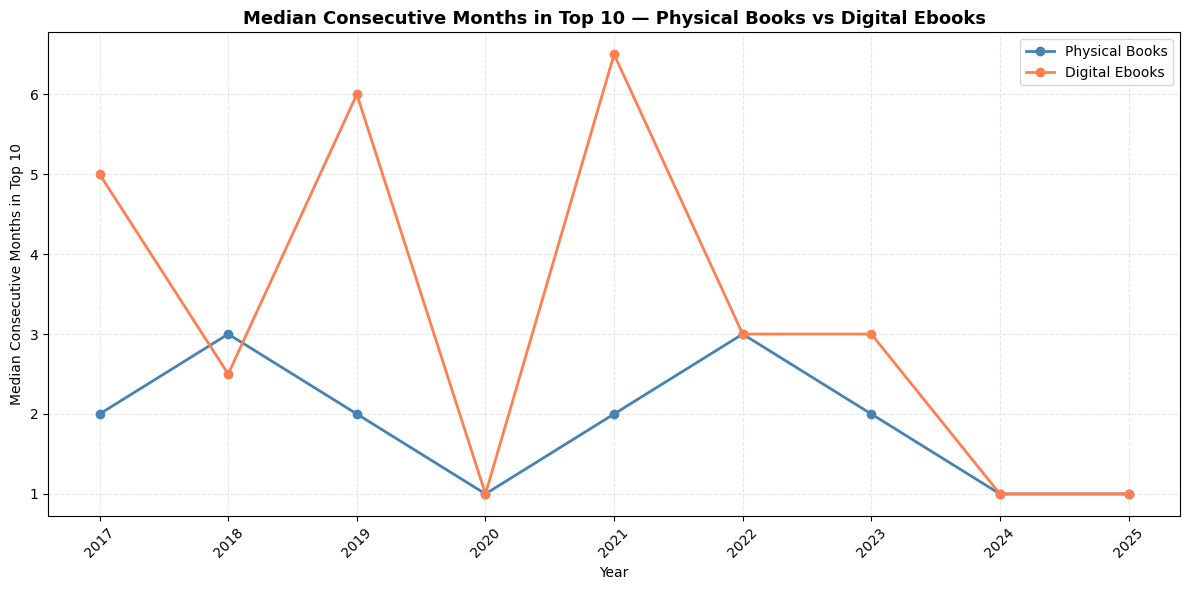

In [14]:
# Plot consecutive months in top 10 aggregated (median) across all years
# Compute median consecutive months by year for books and ebooks
book_yearly   = (book_consecutive.groupby('entry_year')['max_consecutive']
                 .median().reset_index()
                 .rename(columns={'max_consecutive': 'median_consecutive'}))

ebook_yearly  = (ebook_consecutive.groupby('entry_year')['max_consecutive']
                 .median().reset_index()
                 .rename(columns={'max_consecutive': 'median_consecutive'}))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(book_yearly['entry_year'],  book_yearly['median_consecutive'],
        marker='o', linewidth=2, label='Physical Books', color='steelblue')
ax.plot(ebook_yearly['entry_year'], ebook_yearly['median_consecutive'],
        marker='o', linewidth=2, label='Digital Ebooks', color='coral')

ax.set_title('Median Consecutive Months in Top 10 — Physical Books vs Digital Ebooks',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Median Consecutive Months in Top 10')
ax.set_xticks(sorted(book_yearly['entry_year'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/audriswong/data-portfolio/projects/seattle-checkouts/outputs/figures/median_survival_by_year.png',
            dpi=150, bbox_inches='tight')
plt.show()

#### Learnings:
##### Historically, top ebook titles stay in the top 10 for 3–7 consecutive months (median), with notable exceptions in 2018 and 2020.  By comparison, top physical book titles have a shorter popularity tenure, with a median of 1–3 consecutive months. 
##### Since 2024, both formats have converged to a median of 1 consecutive month in the top 10.  This shortening (especially for digital works) suggests patron interest in specific titles is becoming more volatile and shorter-lived. 
##### This might be caused by shortening social media discovery cycles (BookTok), which creates brief, intense spikes in patron interest that fade quickly, particularly for ebooks borrowed on the same devices used for social media.

In [15]:
##what are the outlier books with 20+ mo staying power?

print(f"=== Most Popular Physical Books by Top 10 List staying power ===")
print(book_consecutive.sort_values('max_consecutive', ascending = False).head(10))

print(f"\n === Most Popular EBooks by Top 10 List staying power ===")
print(ebook_consecutive.sort_values('max_consecutive', ascending = False).head(10))

=== Most Popular Physical Books by Top 10 List staying power ===
                                              work_key  max_consecutive  \
163             LESSONS IN CHEMISTRY || GARMUS, BONNIE               13   
408                THE VANISHING HALF || BENNETT, BRIT               13   
452            WHERE THE CRAWDADS SING || OWENS, DELIA               11   
53                         BECOMING || OBAMA, MICHELLE               10   
155               KLARA AND THE SUN || ISHIGURO, KAZUO                9   
76   CASTE : THE ORIGINS OF OUR DISCONTENTS || WILK...                9   
131  HILLBILLY ELEGY : A MEMOIR OF A FAMILY AND CUL...                8   
354                  THE LIBRARY BOOK || ORLEAN, SUSAN                8   
103              EDUCATED : A MEMOIR || WESTOVER, TARA                8   
407  THE UNDERGROUND RAILROAD : A NOVEL || WHITEHEA...                8   

                genre                                              title  \
163        Historical            

#### Analysis Question:
##### What's the overlap in top 10 list titles between digital ebooks and physical books?  Has this changed over time?

In [16]:
# Match Top 10 Books against Ebook Checkouts to measure overlap in popularity
# Matching criteria: 
## Fuzzy Match on closest author
## Fuzzy Match on closest title AND then return title with the highest count of title words directly matched (minimum 1)
# more details on matching algorithm development found in 05_title_matching.ipynb file

#rank add monthly checkout ranking per work to all titles
def works_with_monthly_rank(df, year_col='checkoutyear', month_col='checkoutmonth'):
    results = []
    for (year, month), group in df.groupby([year_col, month_col]):
        ranked = (group.groupby('work_key')
                .agg(total_checkouts=('checkouts', 'sum'),
                     genre=('genre', 'first'),
                     title=('title', 'first'),
                     creator=('creator_clean', 'first'),
                     month_date = ('month_date', 'first'))
                .reset_index()
                .sort_values('total_checkouts', ascending=False))
        ranked['month_checkout_rank'] = range(1, len(ranked) + 1)
        ranked['checkoutyear']  = year
        ranked['checkoutmonth'] = month
        results.append(ranked)
    return pd.concat(results, ignore_index=True)

book_ranked  = works_with_monthly_rank(book_checkouts)
ebook_ranked = works_with_monthly_rank(ebook_checkouts)

In [17]:
# Define matching functions
## Return closest fuzzy match author
## Return closest fuzzy match title that matches 75%+ of meaningful words from the book title
def fuzzy_cross_rank(book_df, ebook_df, book_rank_cutoff=5,
                         author_threshold=70, min_substring_len=3):
    """
    Match on author first, then title.
    Return closest title match that also shares at least 1 meaningful word.
    """
    results = []
    
    noise = {'a', 'an', 'the', 'of', 'in', 'and', 'or', 'to', 'by', 'for',
             'novel', 'memoir', 'story', 'book', 'vol', 'volume'}

    def clean_author(author):
        author = re.sub(r'\(.*?\)', '', str(author))
        author = re.sub(r',?\s*(JR|SR|II|III|IV)\.?', '', author, flags=re.IGNORECASE)
        author = re.sub(r',?\s*\d{4}-?(\d{4})?', '', author)
        return author.strip()

    def get_meaningful_words(title, author=None):
        words = set(re.sub(r'[^a-z0-9\s]', ' ', str(title).lower()).split())
        author_words = set(re.sub(r'[^a-z0-9\s]', ' ', str(author).lower()).split()) if author else set()
        return [w for w in words 
                if w not in noise 
                and len(w) >= min_substring_len
                and w not in author_words]

    for (year, month), book_group in book_df[book_df['month_checkout_rank'] <= book_rank_cutoff].groupby(['checkoutyear', 'checkoutmonth']):
        ebook_month   = ebook_df[(ebook_df['checkoutyear'] == year) &
                                  (ebook_df['checkoutmonth'] == month)].drop_duplicates('title')
        ebook_authors = ebook_month['creator'].tolist()

        for _, book_row in book_group.iterrows():
            book_author_clean = clean_author(book_row['creator'])

            # Step 1 — fuzzy match on author, filter above threshold
            author_candidates = process.extract(book_author_clean, ebook_authors,
                                                 scorer=fuzz.token_sort_ratio, limit=10)
            passing_authors = [(score, idx) for _, score, idx in author_candidates
                               if score >= author_threshold]

            if not passing_authors:
                best_match = best_title_score = best_author_score = best_matched_words = None
            else:
                # Step 2 — among passing authors, score each title using WRatio
                # WRatio handles short vs long title comparisons better than token_sort_ratio
                title_candidates = []
                book_words = get_meaningful_words(book_row['title'], book_row['creator'])
                min_words_required = max(1, len(book_words) * .75)  # match at least 75% of meaningful words

                for author_score, idx in passing_authors:
                    candidate     = ebook_month.iloc[idx]
                    title_score   = fuzz.WRatio(book_row['title'], candidate['title'])
                    ebook_lower   = candidate['title'].lower()
                    matched_words = [w for w in book_words if w in ebook_lower]

                    # Only consider candidates matching >= half # meaningful words in book title
                    if len(matched_words) >= min_words_required:
                        title_candidates.append((title_score, author_score, idx, matched_words))

                if not title_candidates:
                    best_match = best_title_score = best_author_score = best_matched_words = None
                else:
                    # Take the candidate with the highest title score
                    title_candidates.sort(key=lambda x: x[0], reverse=True)
                    best_title_score, best_author_score, idx, best_matched_words = title_candidates[0]
                    best_match = ebook_month.iloc[idx]

            if best_match is not None:
                results.append({
                    'checkoutyear':          year,
                    'checkoutmonth':         month,
                    'month_date':            book_row['month_date'],
                    'book_title':            book_row['title'],
                    'ebook_title':           best_match['title'],
                    'book_author':           book_row['creator'],
                    'ebook_author':          best_match['creator'],
                    'title_score':           best_title_score,
                    'author_score':          best_author_score,
                    'matched_words':         str(best_matched_words),
                    'genre':                 book_row['genre'],
                    'book_rank':             book_row['month_checkout_rank'],
                    'book_total_checkouts':  book_row['total_checkouts'],
                    'ebook_rank':            best_match['month_checkout_rank'],
                    'ebook_total_checkouts': best_match['total_checkouts'],
                })
            else:
                results.append({
                    'checkoutyear':          year,
                    'checkoutmonth':         month,
                    'month_date':            book_row['month_date'],
                    'book_title':            book_row['title'],
                    'ebook_title':           None,
                    'book_author':           book_row['creator'],
                    'ebook_author':          None,
                    'title_score':           None,
                    'author_score':          None,
                    'matched_words':         None,
                    'genre':                 book_row['genre'],
                    'book_rank':             book_row['month_checkout_rank'],
                    'book_total_checkouts':  book_row['total_checkouts'],
                    'ebook_rank':            None,
                    'ebook_total_checkouts': None,
                })

    return pd.DataFrame(results)

In [18]:
# match top 10 physical book titles with top 10 ebook titles per month,
# then return match performance stats

physical_to_ebook_match = fuzzy_cross_rank(book_ranked, ebook_ranked, book_rank_cutoff=10)

total   = len(physical_to_ebook_match)
matched = physical_to_ebook_match['ebook_rank'].notna().sum()

print("=== Match Top 10 Physical Book Works to Top 10 Ebooks ===")
print(f"Total book entries:    {total:,}")
print(f"Matched in ebooks:     {matched:,} ({matched/total*100:.1f}%)")
print(f"Not matched in ebooks: {total-matched:,} ({(total-matched)/total*100:.1f}%)")
print()
for tier in [5, 10, 20, 50]:
    count = (physical_to_ebook_match['ebook_rank'] <= tier).sum()
    print(f"In ebook top {tier:>2}: {count:>5,} ({count/total*100:.1f}%)")

=== Match Top 10 Physical Book Works to Top 10 Ebooks ===
Total book entries:    1,080
Matched in ebooks:     977 (90.5%)
Not matched in ebooks: 103 (9.5%)

In ebook top  5:   104 (9.6%)
In ebook top 10:   147 (13.6%)
In ebook top 20:   272 (25.2%)
In ebook top 50:   438 (40.6%)


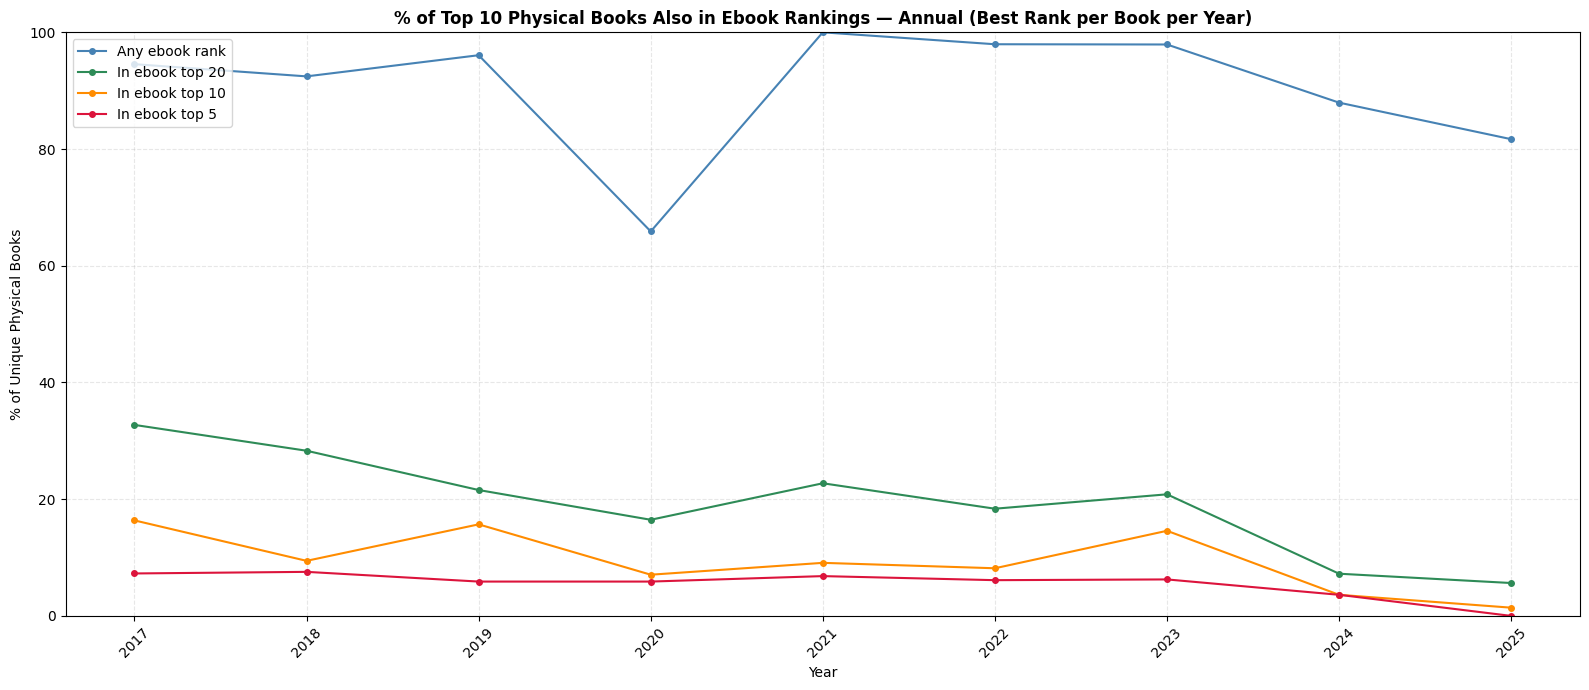

✅ Chart saved
      Unique Books  Matched  Any Match (%)  Top 5 (%)  Top 10 (%)  Top 20 (%)
Year                                                                         
2017            55       52           94.5        7.3        16.4        32.7
2018            53       49           92.5        7.5         9.4        28.3
2019            51       49           96.1        5.9        15.7        21.6
2020            85       56           65.9        5.9         7.1        16.5
2021            44       44          100.0        6.8         9.1        22.7
2022            49       48           98.0        6.1         8.2        18.4
2023            48       47           97.9        6.2        14.6        20.8
2024            83       73           88.0        3.6         3.6         7.2
2025            71       58           81.7        0.0         1.4         5.6


In [19]:
#plot % overlap between top 10 physical books -> ebooks per month to identify general trends

#take the highest ebook rank per book per year
best_rank_per_year = (physical_to_ebook_match
    .groupby(['checkoutyear', 'book_title'])['ebook_rank']
    .min()                        # best (lowest) rank achieved in any month that year
    .reset_index()
)

#aggregate to annual grain
annual_raw = best_rank_per_year.groupby('checkoutyear').agg(
    total     = ('book_title', 'count'),
    matched   = ('ebook_rank', lambda x: x.notna().sum()),
    in_top5   = ('ebook_rank', lambda x: (x <= 5).sum()),
    in_top10  = ('ebook_rank', lambda x: (x <= 10).sum()),
    in_top20  = ('ebook_rank', lambda x: (x <= 20).sum()),
).reset_index()

annual_raw['pct_matched'] = annual_raw['matched'] / annual_raw['total'] * 100
annual_raw['pct_top5']    = annual_raw['in_top5']  / annual_raw['total'] * 100
annual_raw['pct_top10']   = annual_raw['in_top10'] / annual_raw['total'] * 100
annual_raw['pct_top20']   = annual_raw['in_top20'] / annual_raw['total'] * 100

# Plot: monthly (raw) vs annual best-rank side by side 
fig, (ax) = plt.subplots(1, 1, figsize=(16, 7), sharex=False)

#  Bottom panel: annual best-rank view 
ax.plot(annual_raw['checkoutyear'], annual_raw['pct_matched'], label='Any ebook rank',  linewidth=1.5, marker='o', markersize=4, color='steelblue')
ax.plot(annual_raw['checkoutyear'], annual_raw['pct_top20'],   label='In ebook top 20', linewidth=1.5, marker='o', markersize=4, color='seagreen')
ax.plot(annual_raw['checkoutyear'], annual_raw['pct_top10'],   label='In ebook top 10', linewidth=1.5, marker='o', markersize=4, color='darkorange')
ax.plot(annual_raw['checkoutyear'], annual_raw['pct_top5'],    label='In ebook top 5',  linewidth=1.5, marker='o', markersize=4, color='crimson')
ax.set_title('% of Top 10 Physical Books Also in Ebook Rankings — Annual (Best Rank per Book per Year)',
              fontsize=12, fontweight='bold')
ax.set_ylabel('% of Unique Physical Books')
ax.set_xlabel('Year')
ax.set_ylim(0, 100)
ax.set_xticks(annual_raw['checkoutyear'])
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/audriswong/data-portfolio/projects/seattle-checkouts/outputs/figures/pct_books_in_ebook_rankings_combined.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

# print tabular results
display_df = annual_raw[['checkoutyear','total','matched','pct_matched','pct_top5','pct_top10','pct_top20']].copy()
display_df.columns = ['Year','Unique Books','Matched','Any Match (%)','Top 5 (%)','Top 10 (%)','Top 20 (%)']
print(display_df.set_index('Year').round(1).to_string())

#### Learnings:
##### The overlap between the top 10 physical books and the top 10 ebooks has dropped from 15% -> 1% since 2023. 
##### This divergence confirms that physical and digital formats are increasingly serving reader communities with different tastes, and that they should be treated as complements rather than substitutes in collection development strategy.